# <center> ИССЛЕДОВАНИЕ ДАННЫХ HR-АГЕНТСТВА

## Постановка задачи



HR-агентство изучает тренды на рынке труда в IT. Компания хочет провести исследование на основе данных о зарплатах в сфере Data Science за 2020–2022 годы и получить некоторые выводы.

В процессе своего анализа нам необходимо:



1.   Выяснить, какие факторы влияют на зарплату специалиста Data Scientist.
2.   А также ответить на ключевые вопросы HR-агентства:

*   Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?
*   Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?
*   Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?
*   Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?
*   Если вы найдёте в данных интересные закономерности, также отметьте их в своём анализе.

На каждый вопрос необходимо ответить с уровнем значимости $\alpha=0.05$.

Ответить на вопросы нам помогут данные о зарплатах специалистов в сфере Data Science.

Данные содержат следующие столбцы:

*   *work_year* — год, в котором была выплачена зарплата.
*   *experience_level* — уровень опыта:  
    EN — начальный / младший специалист;  
    MI — средний уровень;  
    SE — старший / эксперт;  
    EX — руководящий / директор.
*   *employment_type* — тип занятости:  
    PT — неполный рабочий день;  
    FT — полный рабочий день;  
    CT — контракт;  
    FL — фриланс.
*   *job_title* — должность.
*   *salary* — общая валовая сумма заработной платы.
*   *salary_currency* — валюта зарплаты (код ISO 4217).
*   *salary_in_usd* — зарплата, пересчитанная в доллары США.
*   *employee_residence* — страна проживания сотрудника (код ISO 3166).
*   *remote_ratio* — доля удалённой работы:  
    0 — удалённой работы нет (менее 20%);  
    50 — частично удалённая;  
    100 — полностью удалённая (более 80%).
*   *company_location* — страна расположения главного офиса работодателя (код ISO 3166).
*   *company_size* — размер компании:  
    S — менее 50 сотрудников (небольшая);  
    M — от 50 до 250 (средняя);  
    L — более 250 (крупная).

Источник датасета: ["Data Science Job Salaries" (kaggle.com)](https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries)

## 1. Загрузка данных и обработка данных

### 1.1. Загружаем данные и импортируем необходимые библиотеки

In [1]:
# Загружаем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# Настройка визуализации
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Загружаем данные
df = pd.read_csv('ds_salaries.csv', index_col=0)

# Первичный просмотр
print("Первые 5 строк:")
display(df.head())


Первые 5 строк:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [3]:
# задаём уровень значимости
alpha = 0.05
print("Уровень значимости alpha = {:.2f}".format(alpha))

Уровень значимости alpha = 0.05


### 1.2. Проверяем датасет на наличие пропусков и дубликатов, а также на корректность типов данных столбцов

In [4]:
print("Информация о датафрейме:")
df.info()
print("\nСтатистика числовых признаков:")
display(df.describe())

Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
Index: 607 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   salary              607 non-null    int64 
 5   salary_currency     607 non-null    object
 6   salary_in_usd       607 non-null    int64 
 7   employee_residence  607 non-null    object
 8   remote_ratio        607 non-null    int64 
 9   company_location    607 non-null    object
 10  company_size        607 non-null    object
dtypes: int64(4), object(7)
memory usage: 56.9+ KB

Статистика числовых признаков:


,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,6.070000e+02,607.000000,607.00000
mean,2021.405272,3.240001e+05,112297.869852,70.92257
std,0.692133,1.544357e+06,70957.259411,40.70913
min,2020.000000,4.000000e+03,2859.000000,0.00000
25%,2021.000000,7.000000e+04,62726.000000,50.00000
50%,2022.000000,1.150000e+05,101570.000000,100.00000
75%,2022.000000,1.650000e+05,150000.000000,100.00000
max,2022.000000,3.040000e+07,600000.000000,100.00000


В датасете 607 записей (без пропущенных значений). Данные корректные.

Проверим данные на наличие полных дубликатов:

In [5]:
print('Количество дубликатов: {}'.format(df[df.duplicated()].shape[0]))

# Удаляем дубликаты:
df = df.drop_duplicates()
print('Размер таблицы после удаления дубликатов: {}'.format(df.shape))

Количество дубликатов: 42
Размер таблицы после удаления дубликатов: (565, 11)


### 1.3. Удаляем неифнормативные признаки

In [6]:
# Удаляем неинформативные признаки: salary и salary_currency, так как есть salary_in_usd
df_clean = df.drop(columns=['salary', 'salary_currency'], errors='ignore')
print("Признаки после удаления:", df_clean.columns.tolist())

Признаки после удаления: ['work_year', 'experience_level', 'employment_type', 'job_title', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']


### 1.4. Классифицируем все признаки на числовые и категориальные

In [7]:
# Классификация признаков на числовые и категориальные
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

print("Числовые признаки:", numeric_cols)
print("Категориальные признаки:", categorical_cols)

Числовые признаки: ['work_year', 'salary_in_usd', 'remote_ratio']
Категориальные признаки: ['experience_level', 'employment_type', 'job_title', 'employee_residence', 'company_location', 'company_size']


### 1.5. Находим основные статистические характеристики для каждого из признаков

In [8]:
# Базовые статистики для числовых
print("Статистика числовых признаков:")
display(df_clean[numeric_cols].describe().round(2))

# Базовые статистики для категориальных
print("\nУникальные значения категориальных признаков:")
for col in categorical_cols:
    print(f"{col}: {df_clean[col].nunique()} уникальных значений")

Статистика числовых признаков:


,work_year,salary_in_usd,remote_ratio
count,565.00,565.00,565.00
mean,2021.36,110610.34,69.91
std,0.70,72280.70,40.90
min,2020.00,2859.00,0.00
25%,2021.00,60757.00,50.00
50%,2021.00,100000.00,100.00
75%,2022.00,150000.00,100.00
max,2022.00,600000.00,100.00



Уникальные значения категориальных признаков:
experience_level: 4 уникальных значений
employment_type: 4 уникальных значений
job_title: 50 уникальных значений
employee_residence: 57 уникальных значений
company_location: 50 уникальных значений
company_size: 3 уникальных значений


In [9]:
#посмотрим, как распределены зарплаты по годам
print(df['work_year'].value_counts(normalize=True).sort_index())
#а также удалёнку
print(df['remote_ratio'].value_counts(normalize=True).sort_index())

work_year
2020    0.127434
2021    0.380531
2022    0.492035
Name: proportion, dtype: float64
remote_ratio
0      0.214159
50     0.173451
100    0.612389
Name: proportion, dtype: float64


### Вывод

После загрузки и предварительной обработки получили датасет, содержащий **565 записей** о зарплатах в сфере Data Science за 2020–2022 годы. Пропуски отсутствуют, убрали 42 дубликата. Для анализа оставлены 9 признаков, из которых 3 числовых и 6 категориальных.

- **work_year**: данные распределены между 2020 (12.7%), 2021 (38.1%) и 2022 (49.2%). Около половины записей приходится на 2022 год, что позволяет анализировать современные тенденции, но для проверки динамики зарплат важно учитывать все три года.
- **salary_in_usd**: распределение зарплат скошено вправо (среднее выше медианы), есть значительный разброс (от 2,8 тыс. до 600 тыс. долл.).
- **remote_ratio**: 61,2% специалистов работают полностью удалённо (видимо эффект ковида, интересно сохранился ли тренд сейчас), 17,3% — частично (50%), 21,4% — без удалённой работы (0%).

## Разведывательный анализ данных

## 2. Визуальный анализ

### 2.1. Распределения числовых признаков

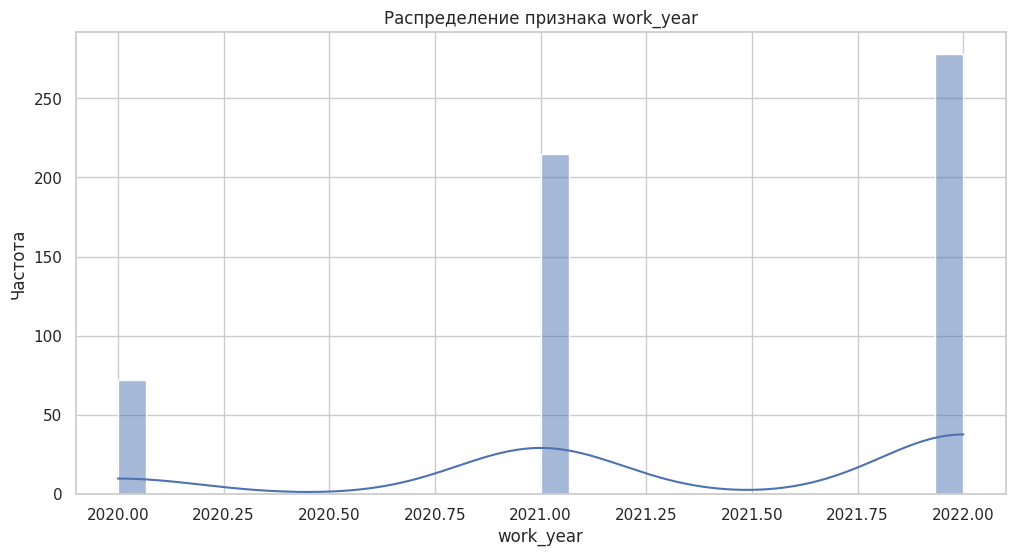

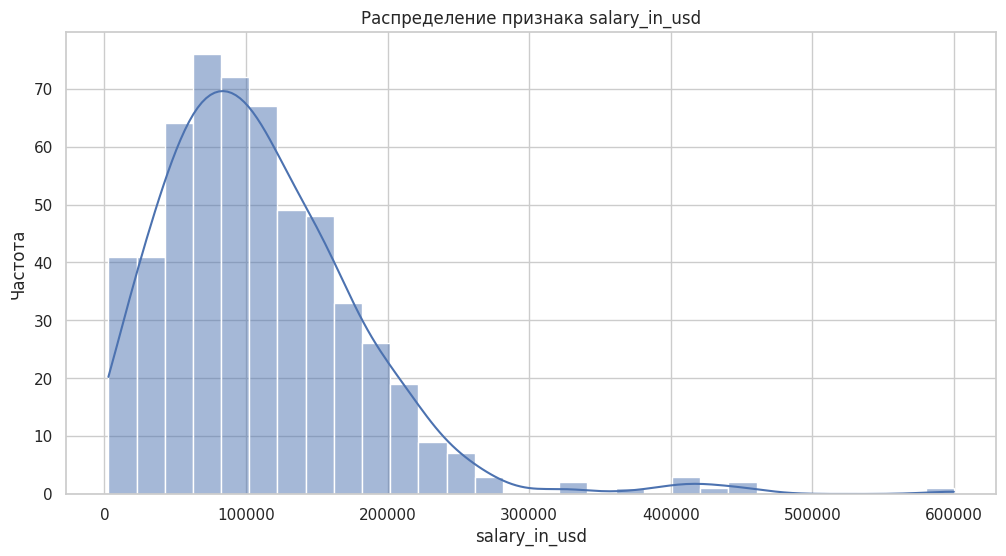

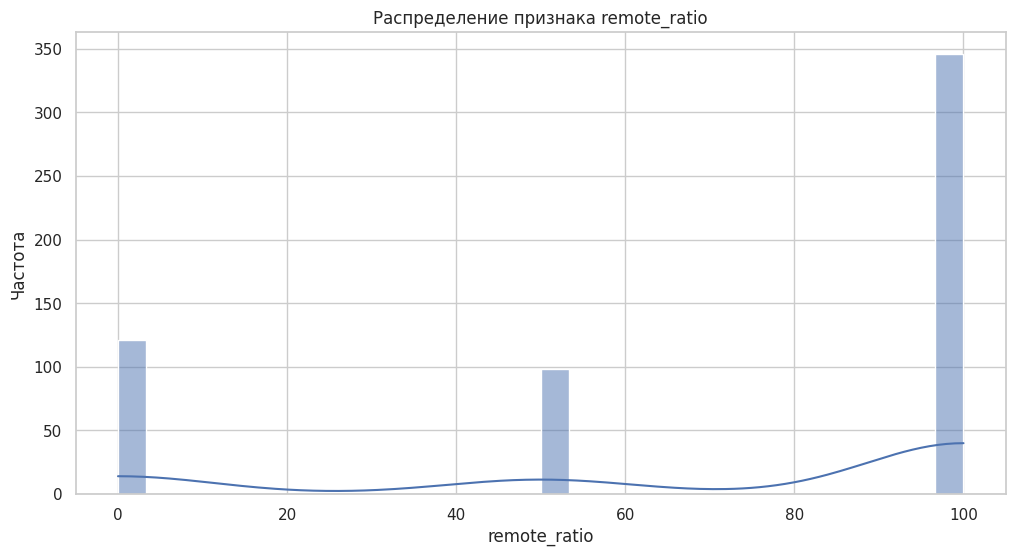

In [10]:
# Гистограммы для числовых признаков
for col in numeric_cols:
    plt.figure()
    sns.histplot(df_clean[col], kde=True, bins=30)
    plt.title(f'Распределение признака {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.show()

Для оценки нормальности распределения salary_in_usd построим QQ-график (квантиль-квантиль). Визуально он покажет, насколько выборочные квантили соответствуют теоретическим квантилям нормального распределения. Если точки ложатся близко к прямой линии, распределение близко к нормальному.

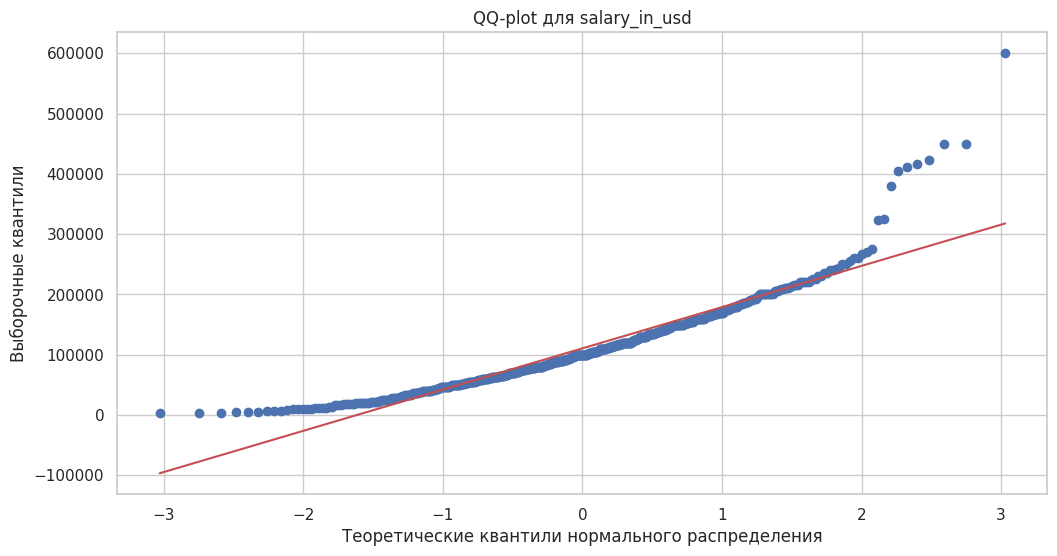

In [11]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# QQ-plot для salary_in_usd
stats.probplot(df['salary_in_usd'], dist="norm", plot=plt)
plt.title('QQ-plot для salary_in_usd')
plt.xlabel('Теоретические квантили нормального распределения')
plt.ylabel('Выборочные квантили')
plt.show()



QQ-график показал отклонение от прямой линии. Это важно для выбора непараметрических тестов в дальнейшем анализе.

### 2.2. Категориальные признаки – количество записей

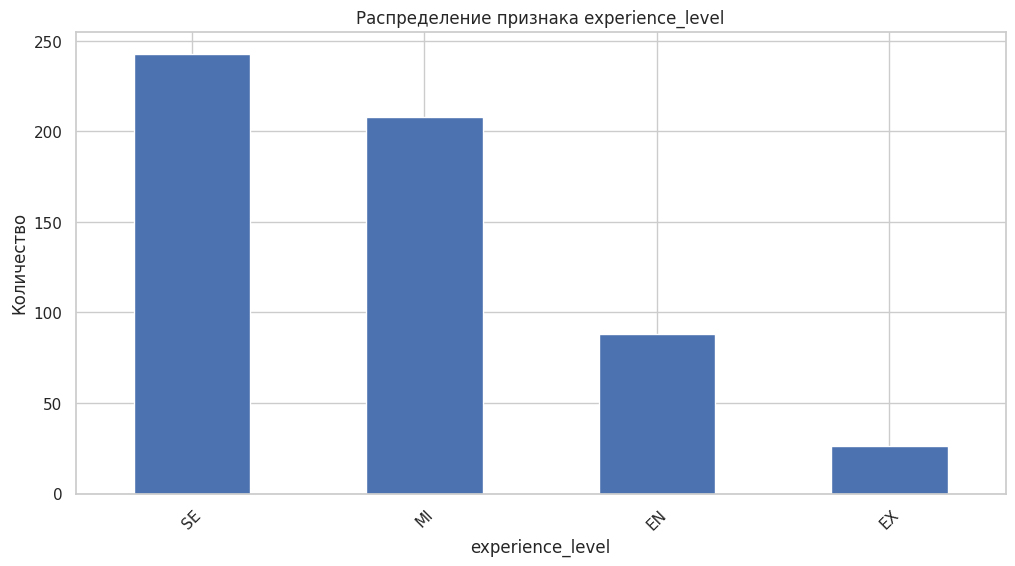

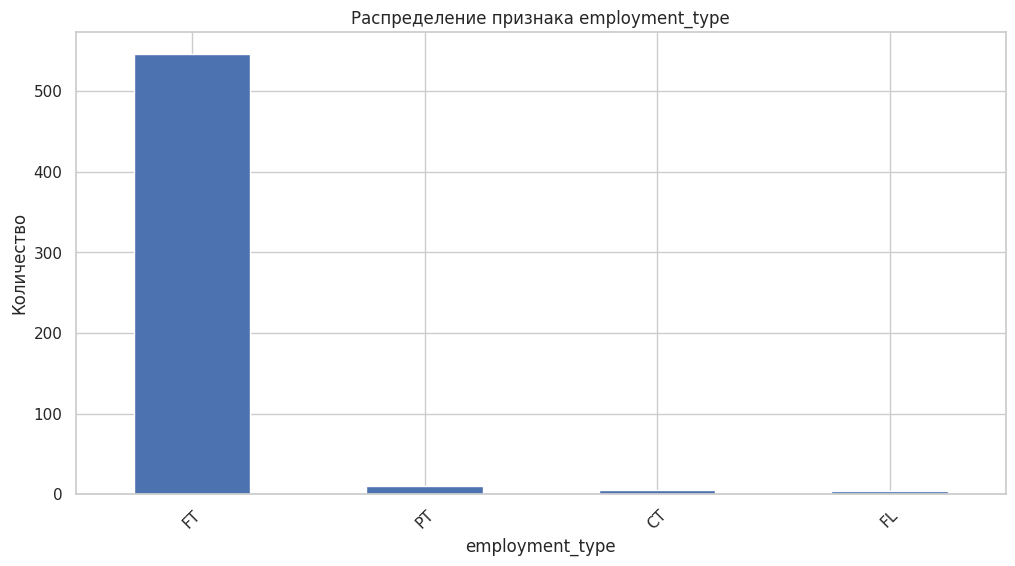

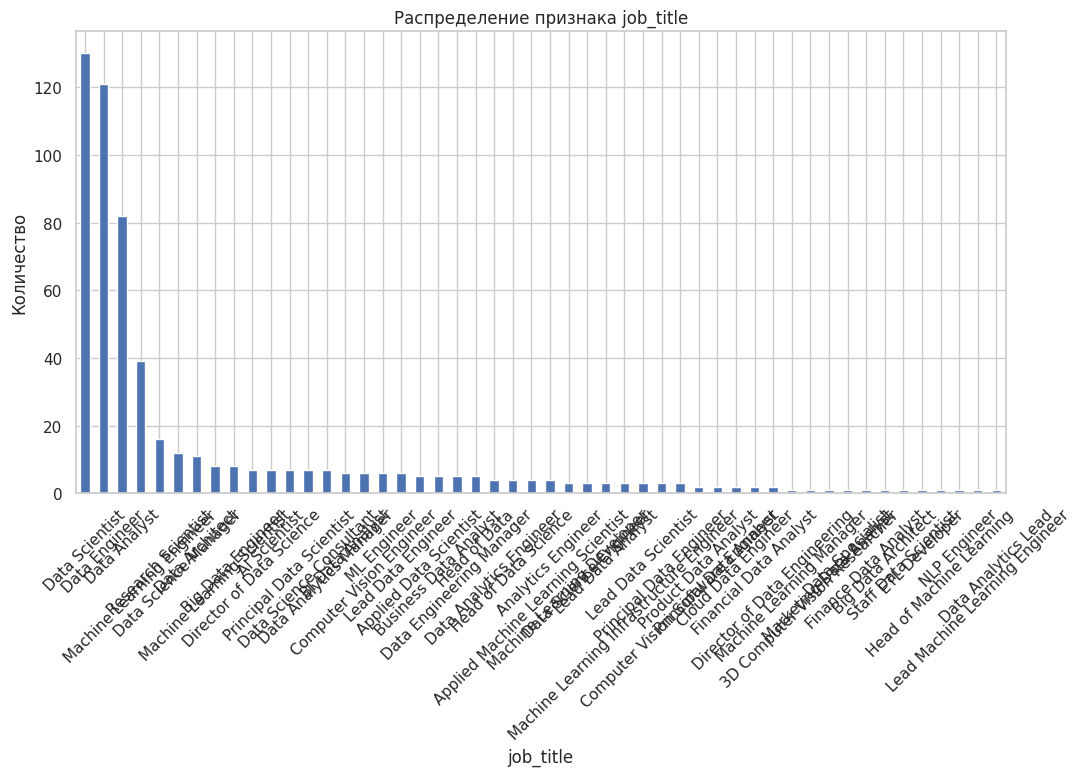

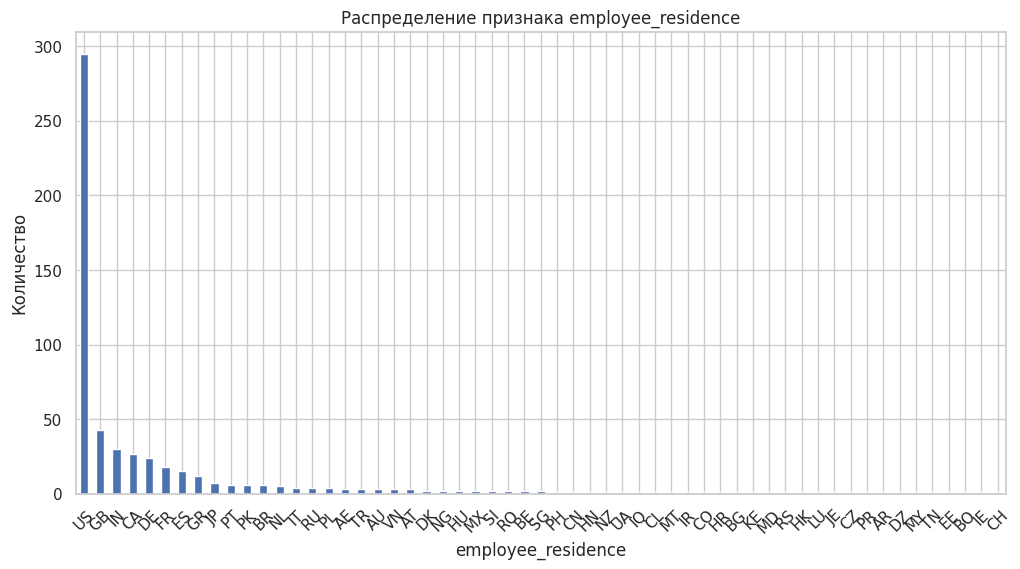

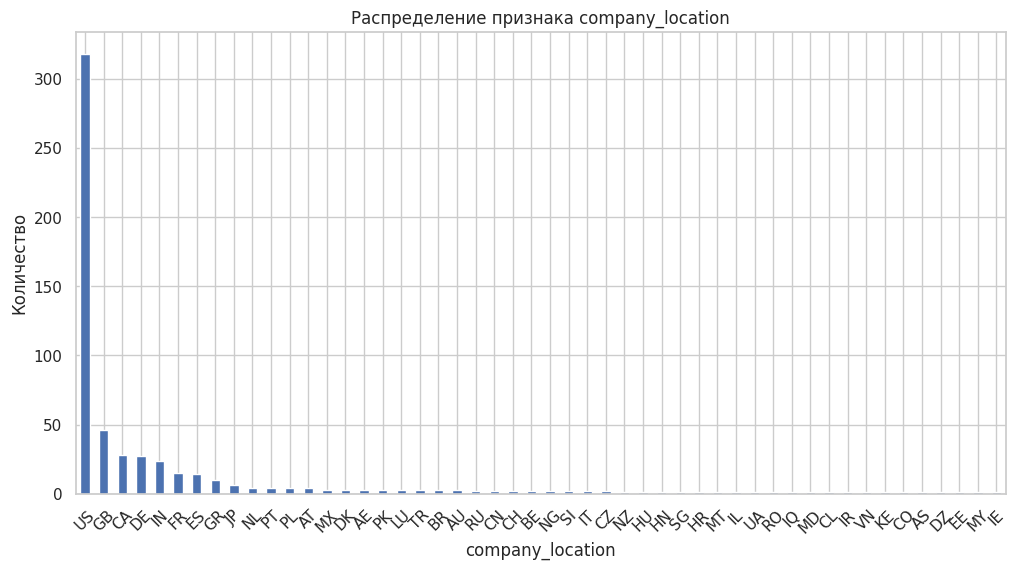

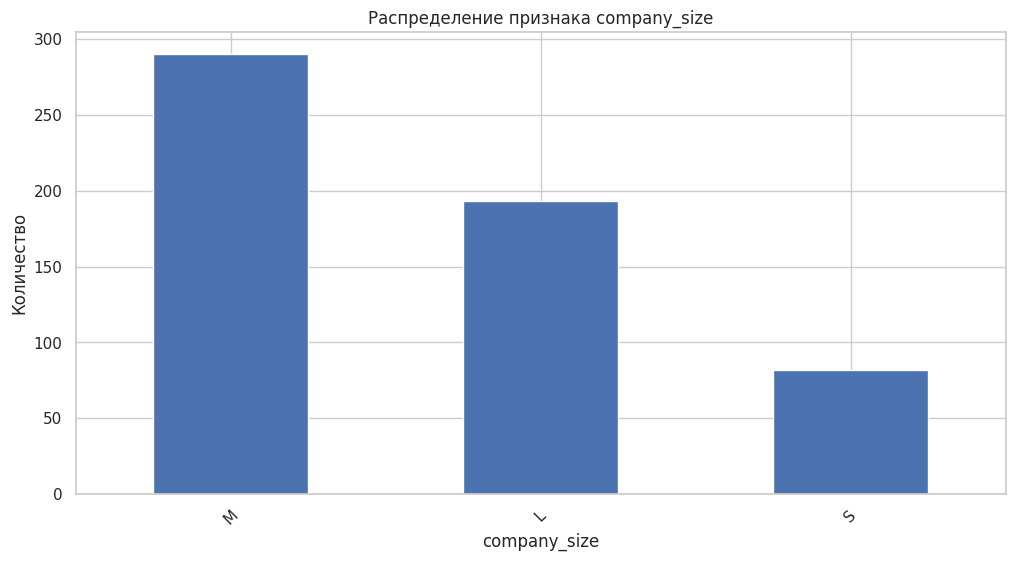

In [12]:
for col in categorical_cols:
    plt.figure()
    df_clean[col].value_counts().plot(kind='bar')
    plt.title(f'Распределение признака {col}')
    plt.xlabel(col)
    plt.ylabel('Количество')
    plt.xticks(rotation=45)
    plt.show()

### 2.3. Влияние факторов на зарплату (salary_in_usd)

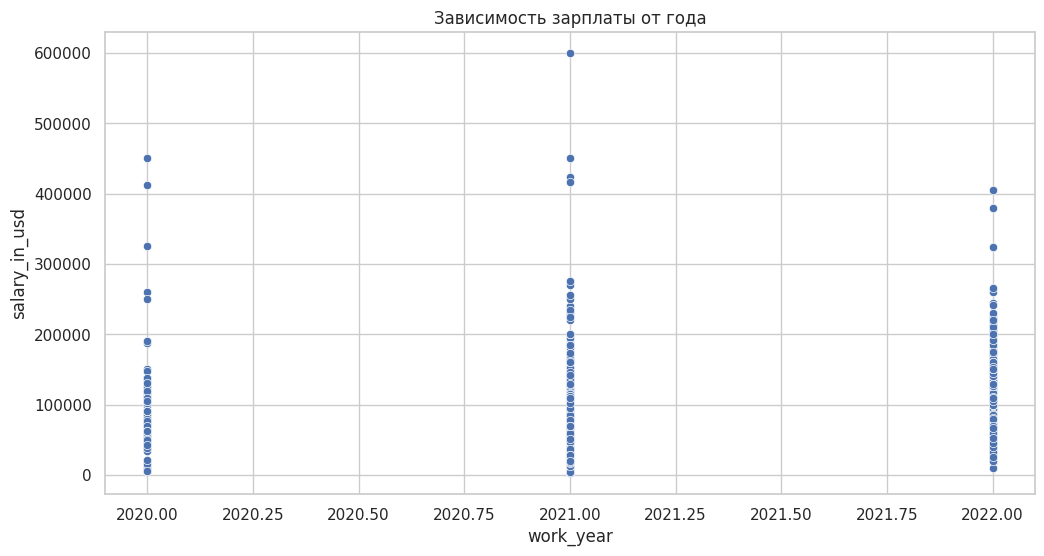

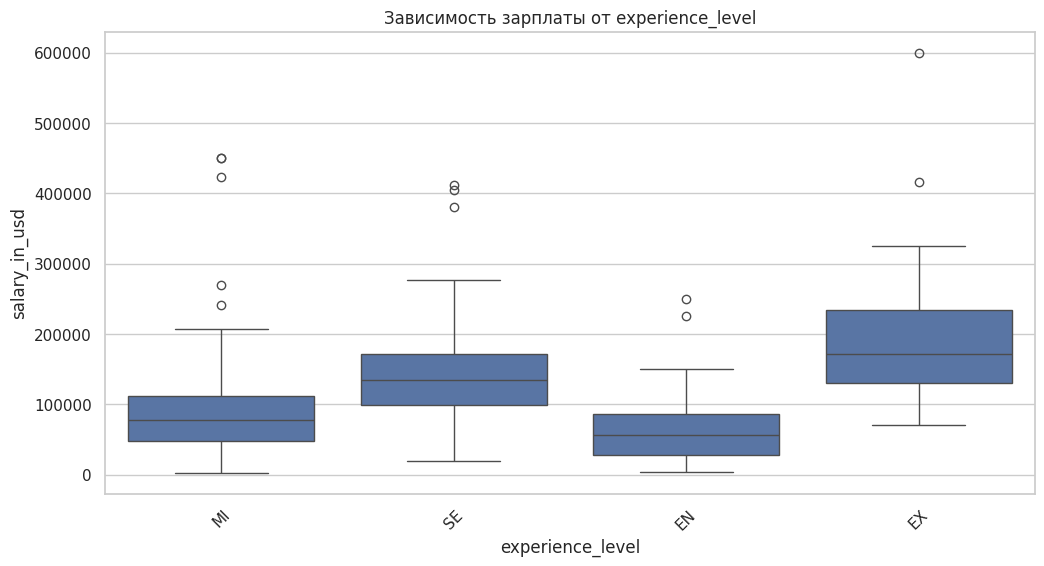

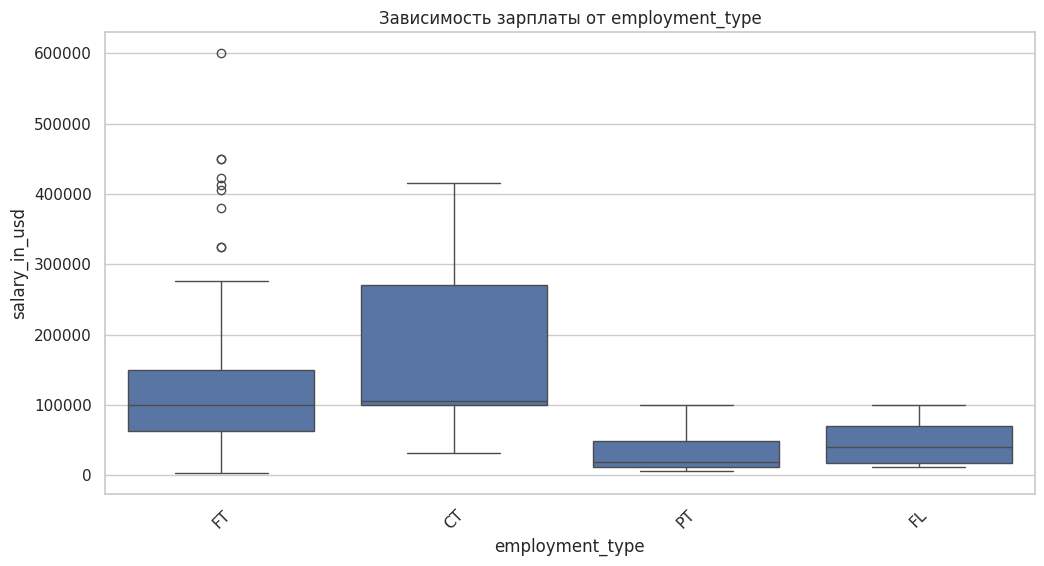

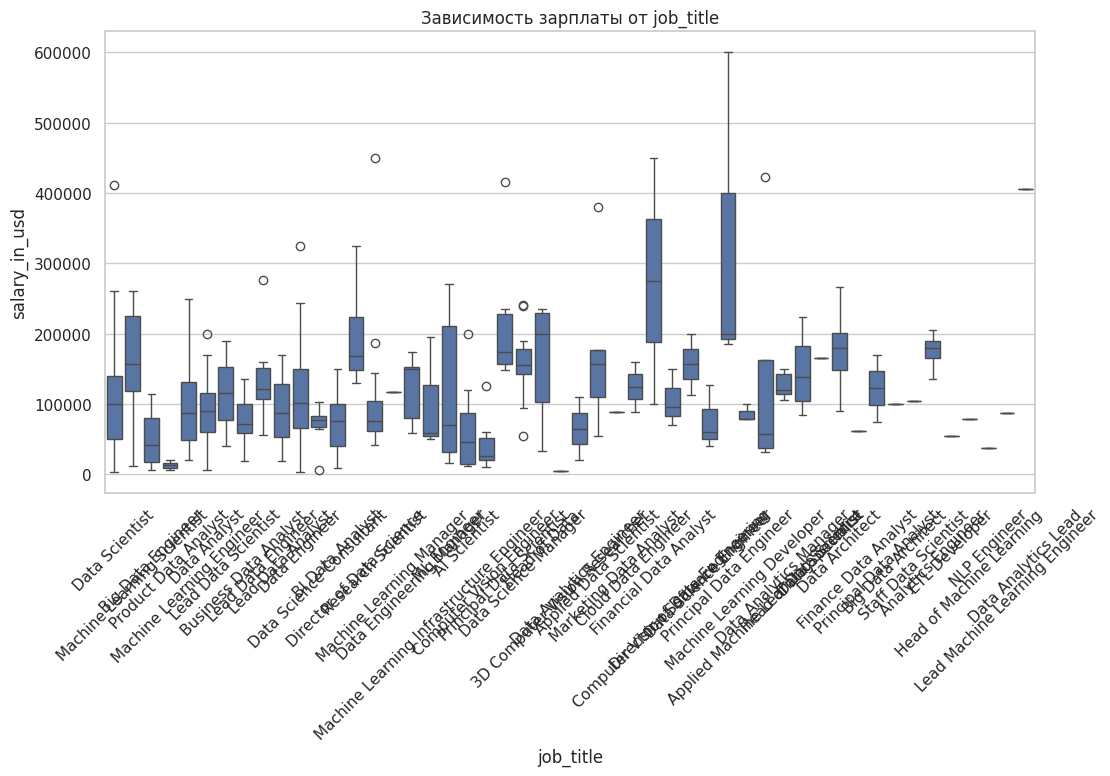

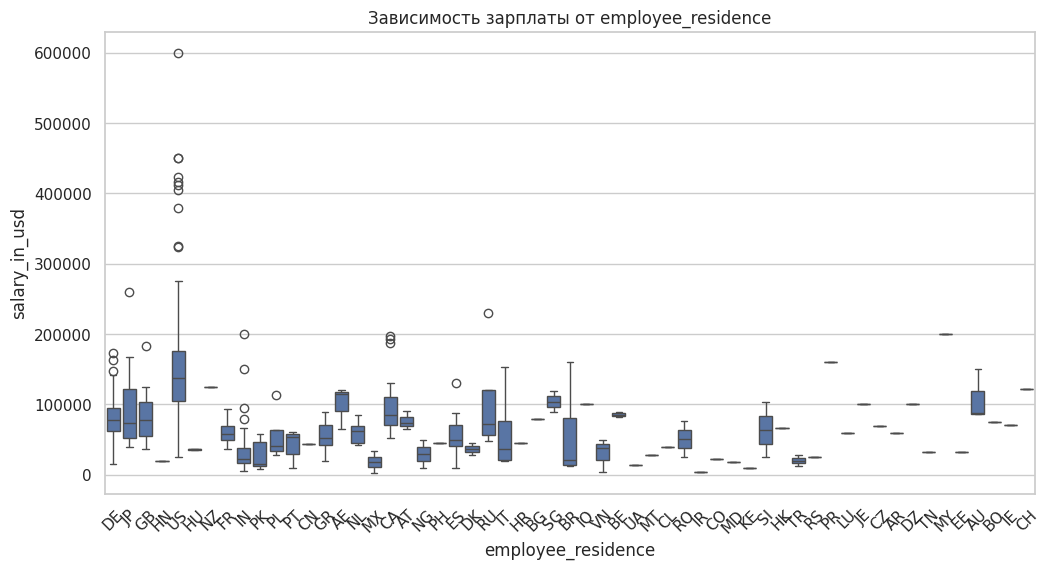

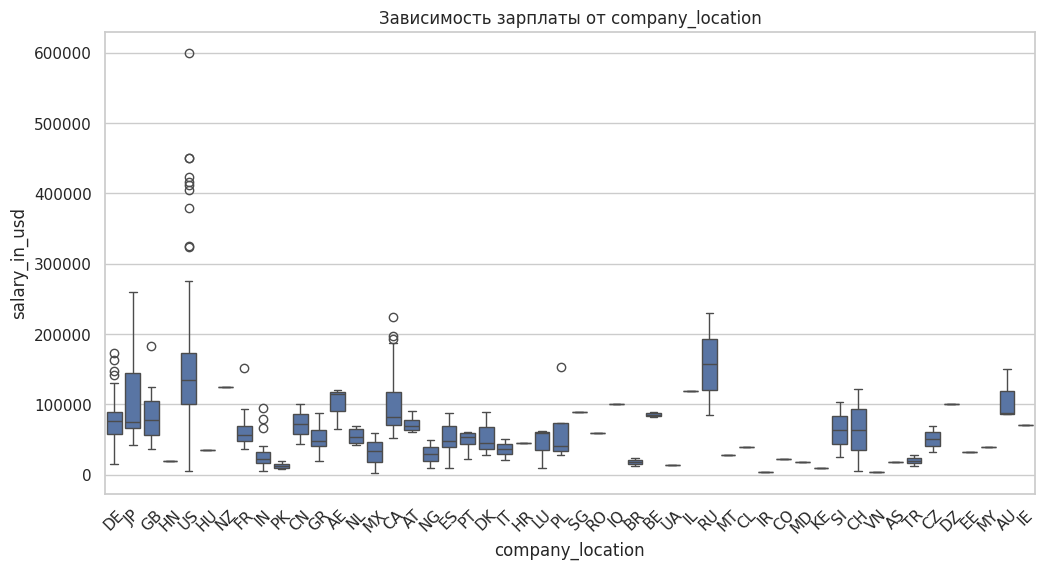

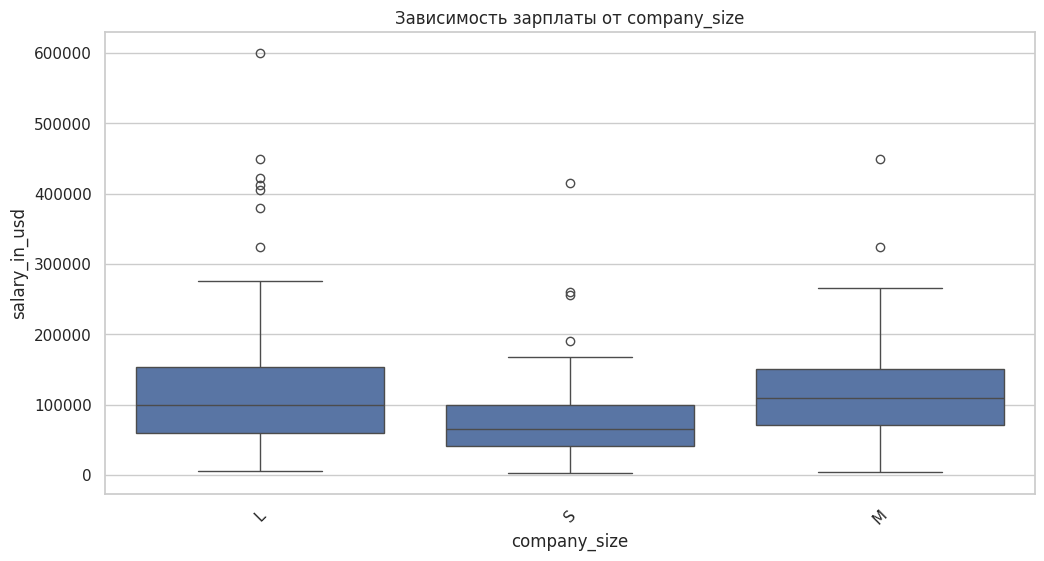

In [13]:
# Для числовых признаков: scatter plot
sns.scatterplot(data=df_clean, x='work_year', y='salary_in_usd')
plt.title('Зависимость зарплаты от года')
plt.show()

# Для категориальных: boxplots
for col in categorical_cols:
    plt.figure()
    sns.boxplot(data=df_clean, x=col, y='salary_in_usd')
    plt.title(f'Зависимость зарплаты от {col}')
    plt.xticks(rotation=45)
    plt.show()

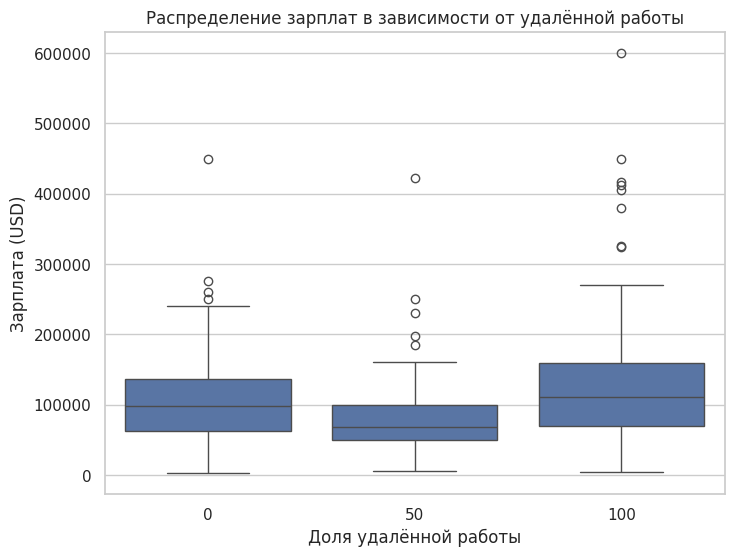

In [14]:
# Визуализация влияния remote_ratio
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='remote_ratio', y='salary_in_usd')
plt.title('Распределение зарплат в зависимости от удалённой работы')
plt.xlabel('Доля удалённой работы')
plt.ylabel('Зарплата (USD)')
plt.show()

### 2.4. Сделаем сравнение зарплат Data Scientist и Data Engineer в 2022 году

/tmp/ipykernel_10699/863242523.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='role', y='salary_in_usd', palette='Set2')


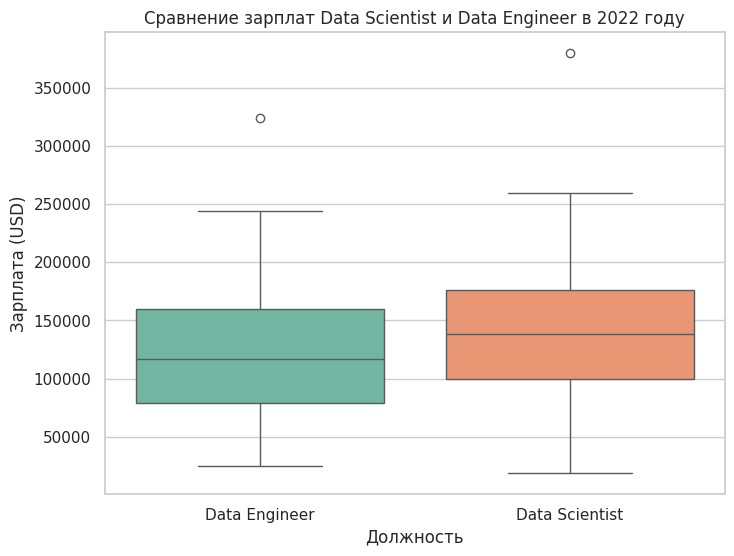

                count       mean      std      min      25%       50%  \
role                                                                    
Data Engineer    80.0  124570.98  57484.1  25000.0  78526.0  116394.5   
Data Scientist   69.0  136456.88  62180.7  18442.0  99360.0  138600.0   

                     75%       max  
role                                
Data Engineer   160020.0  324000.0  
Data Scientist  176000.0  380000.0  


In [30]:
# Фильтруем 2022 год и нужные должности
df_2022 = df_clean[df_clean['work_year'] == 2022].copy()
df_2022['role'] = None
df_2022.loc[df_2022['job_title'].str.contains('Data Scientist', case=False, na=False), 'role'] = 'Data Scientist'
df_2022.loc[df_2022['job_title'].str.contains('Data Engineer', case=False, na=False), 'role'] = 'Data Engineer'
df_plot = df_2022[df_2022['role'].notna()]

# Boxplot
plt.figure(figsize=(8,6))
sns.boxplot(data=df_plot, x='role', y='salary_in_usd', palette='Set2')
plt.title('Сравнение зарплат Data Scientist и Data Engineer в 2022 году')
plt.xlabel('Должность')
plt.ylabel('Зарплата (USD)')
plt.show()

# Описательная статистика
print(df_plot.groupby('role')['salary_in_usd'].describe().round(2))

### 2.5. Анализ для Data Scientist (выделим подвыборку)

Количество записей по Data Scientist: 146


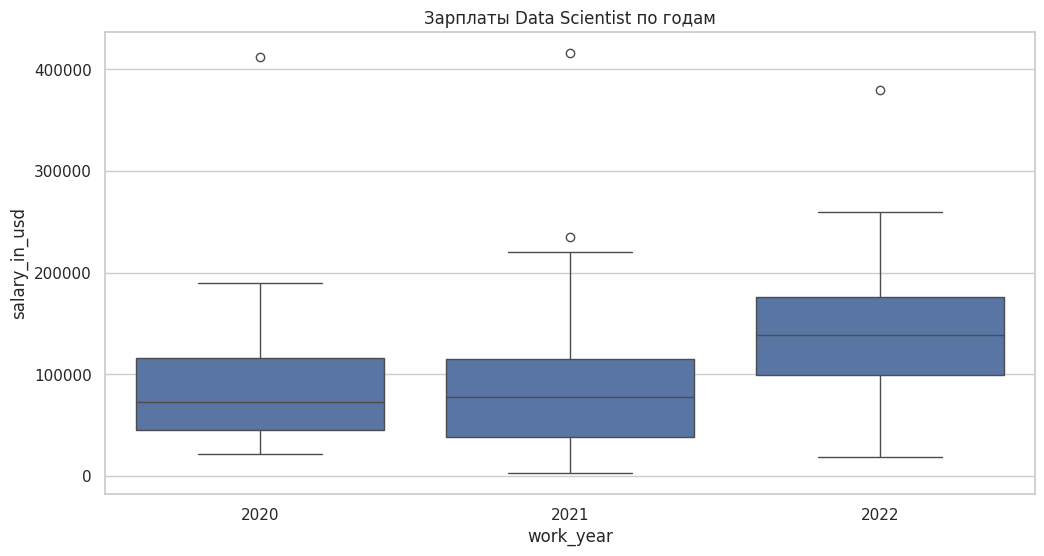

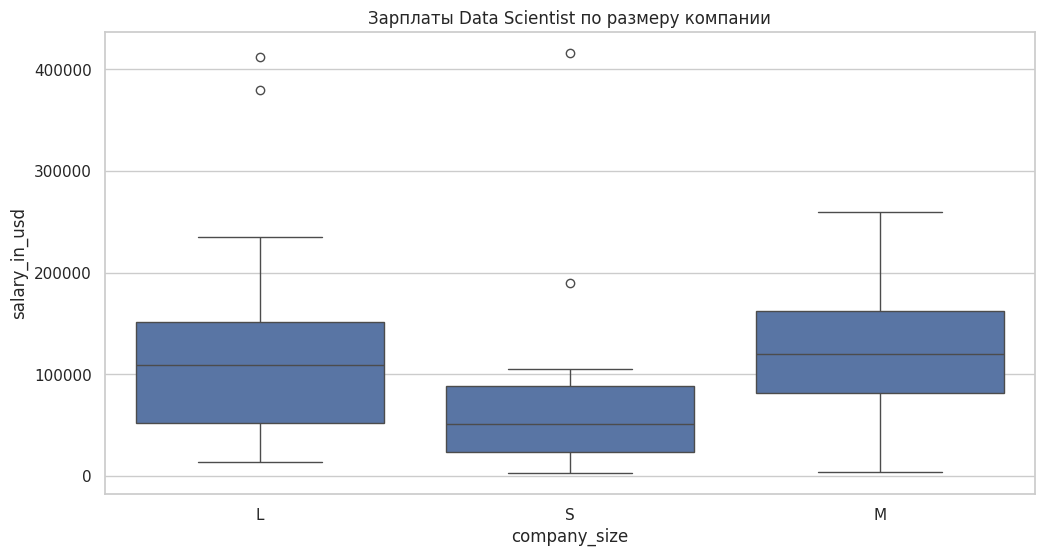

In [16]:
# Создаём подвыборку для Data Scientist
ds_df = df_clean[df_clean['job_title'].str.contains('Data Scientist', case=False, na=False)]
print("Количество записей по Data Scientist:", len(ds_df))

# Визуализация зарплаты Data Scientist по годам
plt.figure()
sns.boxplot(data=ds_df, x='work_year', y='salary_in_usd')
plt.title('Зарплаты Data Scientist по годам')
plt.show()

# По размеру компании
plt.figure()
sns.boxplot(data=ds_df, x='company_size', y='salary_in_usd')
plt.title('Зарплаты Data Scientist по размеру компании')
plt.show()

### Первичные выводы по визуализации

На основе построенных графиков можно сделать предварительные заключения о факторах, влияющих на заработную плату специалистов в сфере Data Science.

### Влияние года
- **Boxplot зарплат по годам** показывает, что медианная зарплата растёт от 2020 к 2022 году.  
- В 2022 году наблюдается наибольший рост значений, что может быть связано с дифицитом кадров и выросшей актуальностью позиции в компаниях

### Влияние опыта (experience_level)
- Зарплаты последовательно увеличиваются с уровнем опыта:  
  **EN** (начальный) < **MI** (средний) < **SE** (старший) < **EX** (руководящий).  
- Разница между уровнями существенна, особенно между MI и SE.

### Влияние должности (job_title)
- Среди анализируемых должностей выделяются **Data Scientist** и **Data Engineer**.  
- Предварительно можно заметить, что **Data Engineer** имеют более высокие медианные зарплаты, чем **Data Scientist** (требует статистической проверки).

### Влияние размера компании (company_size)
- Средние **(M)** и крупные компании **(L)** предлагают более высокие зарплаты по сравнению с малыми **(S)**.  
- Разброс зарплат в крупных компаниях шире, что может отражать разнообразие позиций.

### Влияние удалённой работы (remote_ratio)
- Полностью удалённая работа **(100%)** ассоциируется с более высокими зарплатами, чем частичная удалённость **(50%)** или работа в офисе **(0%)**.  
- Возможная причина: компании, нанимающие удалённых сотрудников, часто конкурируют на глобальном рынке и предлагают более высокие ставки.

### Влияние типа занятости (employment_type)
- Полная занятость **(FT)** доминирует по количеству записей и имеет наиболее высокие зарплаты по сравнению с частичной занятостью **(PT)** и фрилансом **(FL)**.  
- Контрактная занятость **(CT)** имеет наибольший размах по зарплатам, медиана даже чуть выше, чем у полной занятости **(FT)**.

### Географический фактор
- **Страна проживания (employee_residence)** и **страна компании (company_location)**:  
  - США, Великобритания лидируют по количеству записей.  
  - Зарплаты в США значительно выше, чем в других странах (предварительно по boxplot employee_residence).

Все перечисленные наблюдения носят предварительный характер и будут проверены с помощью статистических тестов для подтверждения значимости влияния каждого фактора.

## 3. Статистический анализ данных



Перед тестами проверим нормальность распределения зарплат (для количественного признака) с помощью теста Шапиро-Уилка.

In [17]:
# Тест Шапиро-Уилка
stat, p = stats.shapiro(df['salary_in_usd'])
print(f'p-value (Шапиро-Уилка) = {p:.4f}')
if p > 0.05:
    print("Распределение не отличается от нормального")
else:
    print("Распределение отличается от нормального")

p-value (Шапиро-Уилка) = 0.0000
Распределение отличается от нормального


Тест Шапиро-Уилка дал p-value < 0.05, подтверждая ненормальность. Так как данные не нормальны, будем использовать непараметрические тесты.

Для единообразной интерпретации p‑значений определим вспомогательную функцию:

In [18]:
# Функция для вывода p-value и решения
def decision(p, alpha=0.05):
    print(f'p-value = {p:.4f}')
    if p <= alpha:
        print('Отвергаем нулевую гипотезу (различия статистически значимы).')
    else:
        print('Нет оснований отвергнуть нулевую гипотезу.')

### 3.1. Ежегодный рост зарплат Data Scientist






#### Гипотезы
- **Нулевая гипотеза ($H_0$)**: средние зарплаты Data Scientist одинаковы во все годы (2020–2022).  
 $M_{2020}$ = $M_{2021}$ = $M_{2022}$
- **Альтернативная гипотеза ($H_1$)**: хотя бы один год отличается (различия существуют).

#### Выбор статистического теста
- **Тип признака «Зарплата»**: количественный.
- **Количество групп**: три (2020, 2021, 2022).
- **Группы независимы**.
- **Распределение зарплат отличается от нормального** (проверено ранее).

Для выявления любых различий между годами применяется **критерий Краскела‑Уоллиса** – непараметрический аналог однофакторного дисперсионного анализа.

#### Проведение теста

In [19]:
# Группы зарплат по годам
groups = [ds_df[ds_df['work_year'] == year]['salary_in_usd'] for year in sorted(ds_df['work_year'].unique())]

# Критерий Краскела-Уоллиса
h_stat, p_value = stats.kruskal(*groups)
print("Критерий Краскела-Уоллиса для сравнения зарплат по годам")
decision(p_value)   # функция decision выводит p-value и заключение

Критерий Краскела-Уоллиса для сравнения зарплат по годам
p-value = 0.0000
Отвергаем нулевую гипотезу (различия статистически значимы).


**Вывод**

На уровне значимости $\alpha = 0.05$ **отвергаем нулевую гипотезу**: между зарплатами Data Scientist в 2020, 2021 и 2022 годах существуют статистически значимые различия.

### 3.2. Сравнение зарплат Data Scientist и Data Engineer в 2022 году





#### Гипотезы
- **Нулевая гипотеза ($H_0$)**: зарплаты Data Scientist и Data Engineer в 2022 году статистически не различаются.
- **Альтернативная гипотеза ($H_1$)**: зарплаты различаются (двусторонняя проверка).  
  При необходимости можно уточнить направление: зарплата Data Scientist больше (или меньше).

#### Выбор статистического теста
- **Тип признака «Зарплата»**: количественный.
- **Количество групп**: две (DS и DE).
- **Группы независимы** (разные специалисты).
- **Распределение зарплат отличается от нормального**.

В этих условиях для сравнения двух независимых выборок применяется **U-критерий Манна‑Уитни**.

#### Проведение теста

In [20]:
# Фильтруем 2022 год
df_2022 = df_clean[df_clean['work_year'] == 2022]

# Зарплаты Data Scientist и Data Engineer
salary_ds = df_2022[df_2022['job_title'].str.contains('Data Scientist', case=False)]['salary_in_usd']
salary_de = df_2022[df_2022['job_title'].str.contains('Data Engineer', case=False)]['salary_in_usd']

# Двусторонний тест Манна‑Уитни
u_stat, p_value = stats.mannwhitneyu(salary_ds, salary_de, alternative='two-sided')
print("Сравнение зарплат DS и DE в 2022 г.")
decision(p_value)

# Если есть гипотеза о том, что DS получают больше, замените alternative='greater'
# u_stat, p_value = stats.mannwhitneyu(salary_ds, salary_de, alternative='greater')

Сравнение зарплат DS и DE в 2022 г.
p-value = 0.1687
Нет оснований отвергнуть нулевую гипотезу.


**Интерпретация**

Несмотря на то, что средняя и медианная зарплата Data Scientist в выборке выше (136 457 против 124 571, медиана 138 600 против 116 395) (Описательную статистику делали в блоке по визуализации), разница не достигает статистической значимости. Возможные причины:

- Небольшие размеры выборок (80 и 69 наблюдений).
- Высокая вариативность зарплат внутри каждой группы (стандартные отклонения ~57–62 тыс.).
- Перекрытие распределений: многие значения из обеих групп лежат в общем диапазоне.

**Вывод**

На уровне значимости $\alpha = 0.05$ мы не можем утверждать, что зарплаты Data Scientist и Data Engineer в 2022 году статистически различаются. Наблюдаемая разница в средних может быть следствием случайной вариации в выборке.

### 3.3. Зарплаты Data Scientist в компаниях разного размера





#### Гипотезы
- **Нулевая гипотеза ($H_0$)**: зарплаты Data Scientist одинаковы в компаниях разного размера (S, M, L).
- **Альтернативная гипотеза ($H_1$)**: хотя бы один размер компании отличается по уровню зарплат.

#### Выбор статистического теста
- **Тип признака «Зарплата»**: количественный.
- **Количество групп**: три (S, M, L).
- **Группы независимы**.
- **Распределение зарплат отличается от нормального** (проверено ранее).

Для сравнения трёх независимых групп при ненормальном распределении применяется **критерий Краскела‑Уоллиса**.

#### Проведение теста

In [21]:

# Группы зарплат по размеру компании
groups_size = [ds_df[ds_df['company_size'] == size]['salary_in_usd'] for size in ['S', 'M', 'L']]

# Критерий Краскела‑Уоллиса
h_stat, p_value = stats.kruskal(*groups_size)
print("Сравнение зарплат DS по размеру компании")
decision(p_value)   # функция decision выводит p-value и заключение

Сравнение зарплат DS по размеру компании
p-value = 0.0003
Отвергаем нулевую гипотезу (различия статистически значимы).


**Вывод**

На уровне значимости $\alpha = 0.05$ **отвергаем нулевую гипотезу**: существует статистически значимое различие в зарплатах Data Scientist в компаниях разного размера, что подтверждается, в том числе, визуальным анализом.

In [22]:
# функция для принятия решения о нормальности
def decision_normality(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Распределение отлично от нормального'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. Распределение является нормальным'.format(alpha))


# функция для принятия решения об отклонении нулевой гипотезы
def decision_hypothesis(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу в пользу альтернативной.'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))


### 3.4. Связь между наличием должностей Data Scientist и Data Engineer и размером компании





#### Гипотезы
- **Нулевая гипотеза ($H_0$)**: между типом должности (DS/DE) и размером компании нет статистически значимой связи (признаки независимы).
- **Альтернативная гипотеза ($H_1$)**: связь существует (признаки зависимы).

#### Выбор статистического теста
- **Тип признаков**: оба категориальные.
- **Цель**: проверить независимость двух категориальных переменных.
- **Ожидаемые частоты** достаточны для применения.

Для проверки независимости используется **критерий $\chi^2$ (хи-квадрат) Пирсона** для таблицы сопряжённости.

#### Проведение теста

In [23]:
# Создаём столбец с типом должности (DS или DE)
df_roles = df_clean[df_clean['job_title'].str.contains('Data Scientist|Data Engineer', case=False, na=False)]
df_roles['role_type'] = df_roles['job_title'].apply(lambda x: 'DS' if 'Data Scientist' in x else 'DE')

# Таблица сопряжённости
cross_tab = pd.crosstab(df_roles['role_type'], df_roles['company_size'])
print("Таблица сопряжённости:")
display(cross_tab)

# Тест хи-квадрат
chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab)
print("Хи-квадрат тест на независимость")
decision(p_value)   # функция decision выводит p-value и заключение

Таблица сопряжённости:


/tmp/ipykernel_10699/3738595074.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_roles['role_type'] = df_roles['job_title'].apply(lambda x: 'DS' if 'Data Scientist' in x else 'DE')


company_size,L,M,S
role_type,,,
DE,47,86,14
DS,53,70,23


Хи-квадрат тест на независимость
p-value = 0.1233
Нет оснований отвергнуть нулевую гипотезу.


**Вывод**

На уровне значимости $\alpha = 0.05$ **нет оснований отвергнуть нулевую гипотезу**: статистически значимая связь между типом должности (Data Scientist / Data Engineer) и размером компании не обнаружена. Хотя в выборке наблюдаются некоторые различия в распределении (например, доля DE в малых компаниях меньше, чем DS), эти различия могут быть объяснены случайной вариацией и не являются статистически значимыми.

## 4. Дополнительные тесты

### 4.1. Влияние опыта (experience_level) на зарплату Data Scientist

#### Гипотезы
- **Нулевая гипотеза ($H_0$)**: зарплаты Data Scientist одинаковы для разных уровней опыта (EN, MI, SE, EX).
- **Альтернативная гипотеза ($H_1$)**: хотя бы один уровень опыта отличается по уровню зарплат.

#### Выбор статистического теста
- **Тип признака «Зарплата»**: количественный.
- **Количество групп**: четыре (EN, MI, SE, EX).
- **Группы независимы**.
- **Распределение зарплат отличается от нормального** (проверено ранее).

Для сравнения четырёх независимых групп применяется **критерий Краскела‑Уоллиса**.

#### Визуализация

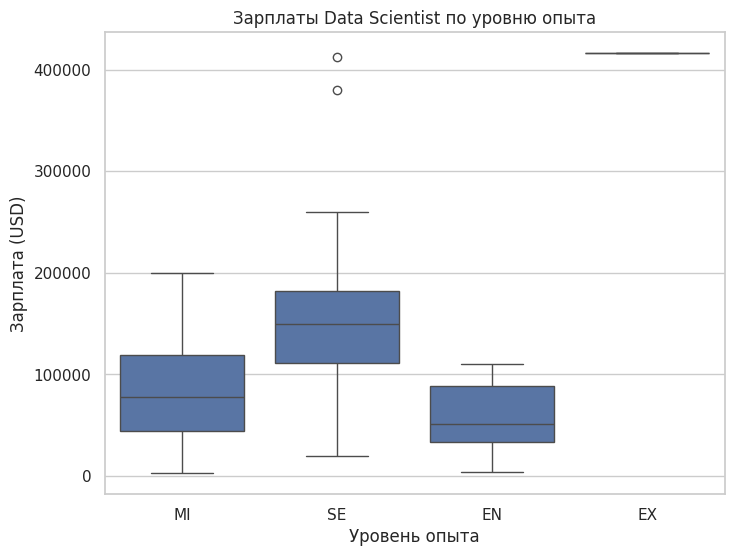

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(data=ds_df, x='experience_level', y='salary_in_usd')
plt.title('Зарплаты Data Scientist по уровню опыта')
plt.xlabel('Уровень опыта')
plt.ylabel('Зарплата (USD)')
plt.show()

**Проведение теста**

In [25]:
from scipy.stats import kruskal

# Группы по уровню опыта
exp_groups = [ds_df[ds_df['experience_level'] == level]['salary_in_usd'] for level in ds_df['experience_level'].unique()]

# Критерий Краскела-Уоллиса
h_stat, p_value = kruskal(*exp_groups)
print("Сравнение зарплат DS по уровню опыта")
decision(p_value)   # функция decision выводит p-value и заключение

Сравнение зарплат DS по уровню опыта
p-value = 0.0000
Отвергаем нулевую гипотезу (различия статистически значимы).


**Вывод**

На уровне значимости $\alpha = 0.05$ **отвергаем нулевую гипотезу**: существует статистически значимое различие в зарплатах Data Scientist в зависимости от уровня опыта. Из boxplot видно, что зарплата последовательно возрастает от начального (EN) к руководящему (EX) уровню.

### 4.2. Влияние удалённой работы (remote_ratio) на зарплату Data Scientist

#### Гипотезы
- **Нулевая гипотеза ($H_0$)**: зарплаты Data Scientist одинаковы для разных уровней удалённой работы (0, 50, 100).
- **Альтернативная гипотеза ($H_1$)**: хотя бы один уровень удалённости отличается по уровню зарплат.

#### Выбор статистического теста
- **Тип признака «Зарплата»**: количественный.
- **Количество групп**: три (0, 50, 100).
- **Группы независимы**.
- **Распределение зарплат отличается от нормального** (проверено ранее).

Для сравнения трёх независимых групп применяется **критерий Краскела‑Уоллиса**.

#### Визуализация

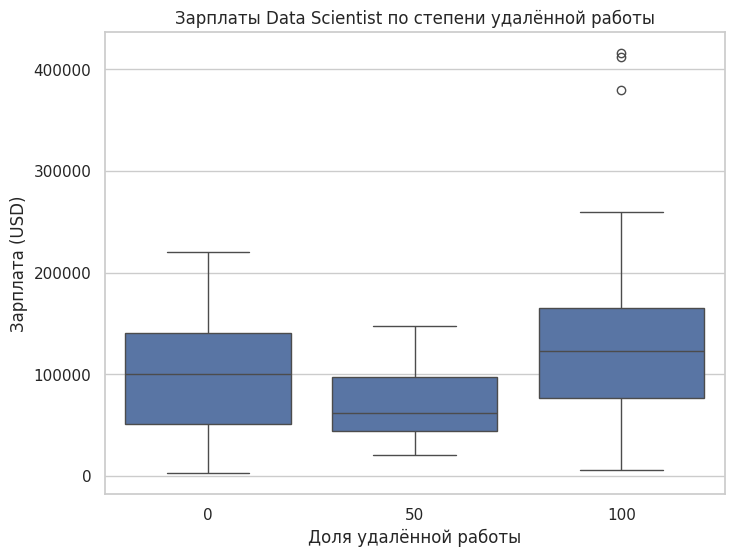

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(data=ds_df, x='remote_ratio', y='salary_in_usd')
plt.title('Зарплаты Data Scientist по степени удалённой работы')
plt.xlabel('Доля удалённой работы')
plt.ylabel('Зарплата (USD)')
plt.show()

**Проведение теста**

In [27]:
from scipy.stats import kruskal

# Группы зарплат по степени удалённости
remote_groups = [ds_df[ds_df['remote_ratio'] == ratio]['salary_in_usd'] for ratio in ds_df['remote_ratio'].unique()]

# Критерий Краскела-Уоллиса
h_stat, p_value = kruskal(*remote_groups)
print("Сравнение зарплат DS по степени удалённости")
decision(p_value)   # функция decision выводит p-value и заключение

Сравнение зарплат DS по степени удалённости
p-value = 0.0010
Отвергаем нулевую гипотезу (различия статистически значимы).


**Вывод**

На уровне значимости $\alpha = 0.05$ **отвергаем нулевую гипотезу**: существует статистически значимое различие в зарплатах Data Scientist в зависимости от степени удалённой работы. По boxplot видно, что полностью удалённые специалисты (100%) имеют более высокие зарплаты, чем работающие в офисе (0%) или частично удалённые (50%).

### 4.3. Проверка гипотезы о медиане зарплаты Data Scientist в 2022 году (тест для одной выборки)




#### Гипотезы
- **Нулевая гипотеза ($H_0$)**: медиана зарплаты Data Scientist в 2022 году ≤ общей медианы.
- **Альтернативная гипотеза ($H_1$)**: медиана зарплаты Data Scientist в 2022 году > общей медианы.

### Выбор теста
- **Тип признака**: количественный (зарплата).
- **Одна выборка** (Data Scientist, 2022 год).
- **Распределение не нормальное**, поэтому применяем **критерий знаковых рангов Уилкоксона** (Wilcoxon signed-rank test) для проверки гипотезы о медиане.

### Проведение теста



Для демонстрации теста для одной выборки проверим, превышает ли медианная зарплата Data Scientist в 2022 году **общую медиану зарплат Data Scientist за все годы** (2020–2022).

#### Вычисление общей медианы

In [28]:
# Общая медиана зарплат Data Scientist за все годы
total_median = ds_df['salary_in_usd'].median()
print(f"Общая медиана зарплат DS за все годы: {total_median:.2f} USD")

Общая медиана зарплат DS за все годы: 104196.50 USD


In [29]:
from scipy.stats import wilcoxon

# Выборка зарплат Data Scientist за 2022 год
salary_ds_2022 = ds_df[ds_df['work_year'] == 2022]['salary_in_usd']

# Проверка: медиана > общей медианы
diff = salary_ds_2022 - total_median
_, p_value = wilcoxon(diff, alternative='greater')
print("Критерий знаковых рангов Уилкоксона для проверки медианы > общей медианы")
decision(p_value)

Критерий знаковых рангов Уилкоксона для проверки медианы > общей медианы
p-value = 0.0000
Отвергаем нулевую гипотезу (различия статистически значимы).


**Вывод**

На уровне значимости $\alpha = 0.05$ **отвергаем нулевую гипотезу**: медианная зарплата Data Scientist в 2022 году статистически значимо превышает общую медиану зарплат за все годы (2020–2022). Это подтверждает наблюдаемый тренд роста зарплат.

## 5. Итоговые выводы по исследованию



В ходе анализа данных о зарплатах специалистов в сфере Data Science (565 записей за 2020–2022 гг. после предвариельной обработки) были изучены факторы, влияющие на уровень оплаты труда, и даны ответы на ключевые вопросы HR-агентства.

### 1. Ежегодный рост зарплат Data Scientist
- **Критерий Краскела‑Уоллиса** выявил статистически значимые различия между зарплатами Data Scientist в 2020, 2021 и 2022 годах (p < 0.001).  
- Медианная зарплата в 2022 году оказалась значимо выше общей медианы за все годы (**критерий Уилкоксона**, p < 0.001).  
- **Вывод:** зарплаты Data Scientist ежегодно растут.

### 2. Сравнение зарплат Data Scientist и Data Engineer в 2022 году
- По описательной статистике средняя зарплата Data Scientist выше (136 457  vs 124 571), однако **U-критерий Манна‑Уитни** не подтвердил значимость различий (p = 0.1687).  
- **Вывод:** на уровне значимости 0,05 нельзя утверждать, что зарплаты двух профессий в 2022 году различаются.

### 3. Влияние размера компании на зарплату Data Scientist
- **Критерий Краскела‑Уоллиса** показал значимые различия между компаниями разного размера (p = 0.0003).  
- Крупные (L) и средние компании (M) предлагают более высокие зарплаты, чем малые (S).  
- **Вывод:** размер компании влияет на уровень оплаты труда Data Scientist.

### 4. Связь между должностью (DS/DE) и размером компании
- **Критерий χ² (хи-квадрат)** не выявил статистически значимой зависимости (p = 0.1233).  
- **Вывод:** распределение должностей Data Scientist и Data Engineer по размерам компаний не имеет значимой связи.

### 5. Дополнительные факторы, влияющие на зарплату Data Scientist
- **Уровень опыта (experience_level)** – значимые различия (p < 0.001): зарплата растёт от начального (EN) к руководящему (EX).
- **Удалённая работа (remote_ratio)** – значимые различия (p = 0.001): полностью удалённые специалисты получают больше.
- **Тип занятости (employment_type)** – полная занятость (FT) преобладает и имеет самые высокие зарплаты, но из-за малого числа наблюдений по другим типам выводы ограничены.

### Общее заключение
Зарплата специалиста Data Scientist определяется преимущественно **годом (тренд роста), уровнем опыта, размером компании и степенью удалённой работы**. Сравнение с Data Engineer в 2022 году не показало устойчивых различий. Связи между типом должности (DS/DE) и размером компании не обнаружено.